In [1]:
import numpy as np
#import numpy.random as npr
import numpy.linalg as nla
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.colors as mcol
from scipy.optimize import curve_fit
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import scipy.stats as sts
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn import linear_model
from sklearn.neighbors import KernelDensity

plt.style.use('./presentation.mplstyle')


In [2]:
sources = pd.read_csv('v1saga_dwarfs.csv')
print(sources.shape)

smorph = pd.read_csv('saga_morph.csv')
print(smorph.shape)

(6337, 26)
(6211, 78)


In [3]:
rd2deg = (180*3600)/np.pi

#mst = sources['logM'].iloc[morph_all[:,0,0]]
#zspec = sources['zspec'].iloc[morph_all[:,0,0]]
#res = 1e6*(0.262*cosmo.comoving_distance(zspec).value)/rd2deg

npar = {1:[[0.3,1.0],r'${\it Gini}$'],2:[[-2,-0.5],r'$M_{20}$'],5:[[1.5,4],r'$Concentration$'],6:[[-0.75,0.75],r'$Asymmetry$'],7:[[-0.1,0.1],r'$Smoothness$']}

def merger_line(M20): return -0.14*M20 + 0.33
def hubble_line(M20): return  0.14*M20 + 0.80
def SGM(G,M20): return 0.139*M20 + 0.99*G - 0.327
def BGM(G,M20): return -0.693*M20 + 4.95*G - 3.96

In [4]:
bands = {'g':[mcm.Blues,'tab:blue'],'r':[mcm.Greens,'tab:green'],'i':[mcm.Oranges,'tab:orange'],'z':[mcm.Reds,'tab:red']}

labels = [r'${\it g}$', r'${\it r}$', r'${\it i}$', r'${\it z}$']
positions = [0, 1, 2, 3]

In [5]:
'''
def gaussian_2d(xy, amplitude, x0, y0, sx, sy, offset):
    x, y = xy
    x_part,y_part = np.square((x - x0) / sx),np.square((y - y0) / sy)
    return offset + amplitude * np.exp(-0.5 * (x_part + y_part))
'''

def gaussian_2d(xy, mu_x, mu_y, sigma_x, sigma_y, rho, norm, offset):
    x, y = xy
    norm_const = norm / (2 * np.pi * sigma_x * sigma_y * np.sqrt(1 - rho**2))
    
    # Standardized coordinates
    x_std = (x - mu_x) / sigma_x
    y_std = (y - mu_y) / sigma_y
    
    # Exponent term
    exponent = -1.0 * (np.square(x_std) - 2*rho*x_std*y_std + np.square(y_std))/(2*(1 - rho**2)) 
    
    return norm_const * np.exp(exponent) + offset


def hess_arr(x_val,y_val,hdex,nbins):
    x_val = (x_val - hdex[0])/(hdex[1]-hdex[0])
    y_val = (y_val - hdex[2])/(hdex[3]-hdex[2])
    dz=1.0/nbins
    
    xx,yy=np.meshgrid(np.arange(dz,1+dz,dz),np.arange(dz,1+2*dz,dz))
    xy_sample = np.vstack([yy[:-1].ravel(), xx[:-1].ravel()]).T
    xy_train  = np.vstack([y_val,x_val]).T

    kde_skl = KernelDensity(kernel='gaussian', bandwidth=0.05)
    kde_skl.fit(xy_train)
    hss_est = np.exp(np.reshape(kde_skl.score_samples(xy_sample),(nbins,nbins)))
    hss_est = hss_est/np.sum(hss_est)

    x_flat,y_flat = xx[:-1].ravel(),yy[:-1].ravel()
    data_flat = hss_est.ravel()

    #initial_guesses = [np.amax(data_flat),np.mean(x_flat),np.mean(y_flat),np.std(x_flat),np.std(y_flat),0.0]
    initial_guesses = [np.mean(x_flat),np.mean(y_flat),np.std(x_flat),np.std(y_flat),-0.8,np.amax(data_flat),np.amin(data_flat)]
    popt, pcov = curve_fit(gaussian_2d,(x_flat, y_flat),data_flat,p0=initial_guesses,bounds=(-2,2))

    #resi = hss_est - gaussian_2d((xx[:-1],yy[:-1]), *popt)

    popt[:4] = popt[0]*(hdex[1]-hdex[0]) + hdex[0], popt[1]*(hdex[3]-hdex[2]) + hdex[2],np.abs(popt[2]*(hdex[1]-hdex[0])),np.abs(popt[3]*(hdex[3]-hdex[2]))
    perr = np.sqrt(np.abs(np.diag(pcov)))
    perr[:4] = np.abs(perr[0]*(hdex[1]-hdex[0])),np.abs(perr[1]*(hdex[3]-hdex[2])),np.abs(perr[2]*(hdex[1]-hdex[0])),np.abs(perr[3]*(hdex[3]-hdex[2]))

    return hss_est,popt,perr


(3698, 78)
[-1.60951571e+00  4.63080744e-01  1.25910063e-01  3.60439676e-02
 -3.65173912e-01  5.57865871e-04  6.85769700e-05] [5.72069151e-04 1.63761016e-04 5.99691832e-04 1.71678699e-04
 5.56956555e-03 3.00141506e-06 5.52357961e-06]
(3947, 78)
[-1.64835297e+00  4.73656538e-01  1.21095448e-01  3.55491432e-02
 -3.78224467e-01  5.62098143e-04  6.46007581e-05] [4.71671154e-04 1.38426623e-04 4.92817834e-04 1.44674686e-04
 4.72118005e-03 2.56291682e-06 4.85496001e-06]
(2357, 78)
[-1.66319687e+00  4.81632513e-01  1.17562006e-01  3.47323336e-02
 -3.59823550e-01  5.42742901e-04  8.39616992e-05] [5.00985892e-04 1.47956877e-04 5.22322895e-04 1.54304998e-04
 5.24715153e-03 2.68615933e-06 5.20343465e-06]
(2415, 78)
[-1.66523031e+00  4.83434484e-01  1.16538928e-01  3.53357430e-02
 -3.99296388e-01  5.44599721e-04  8.20803323e-05] [4.94622791e-04 1.49923882e-04 5.15440191e-04 1.56269090e-04
 5.04627243e-03 2.68042858e-06 5.21598546e-06]


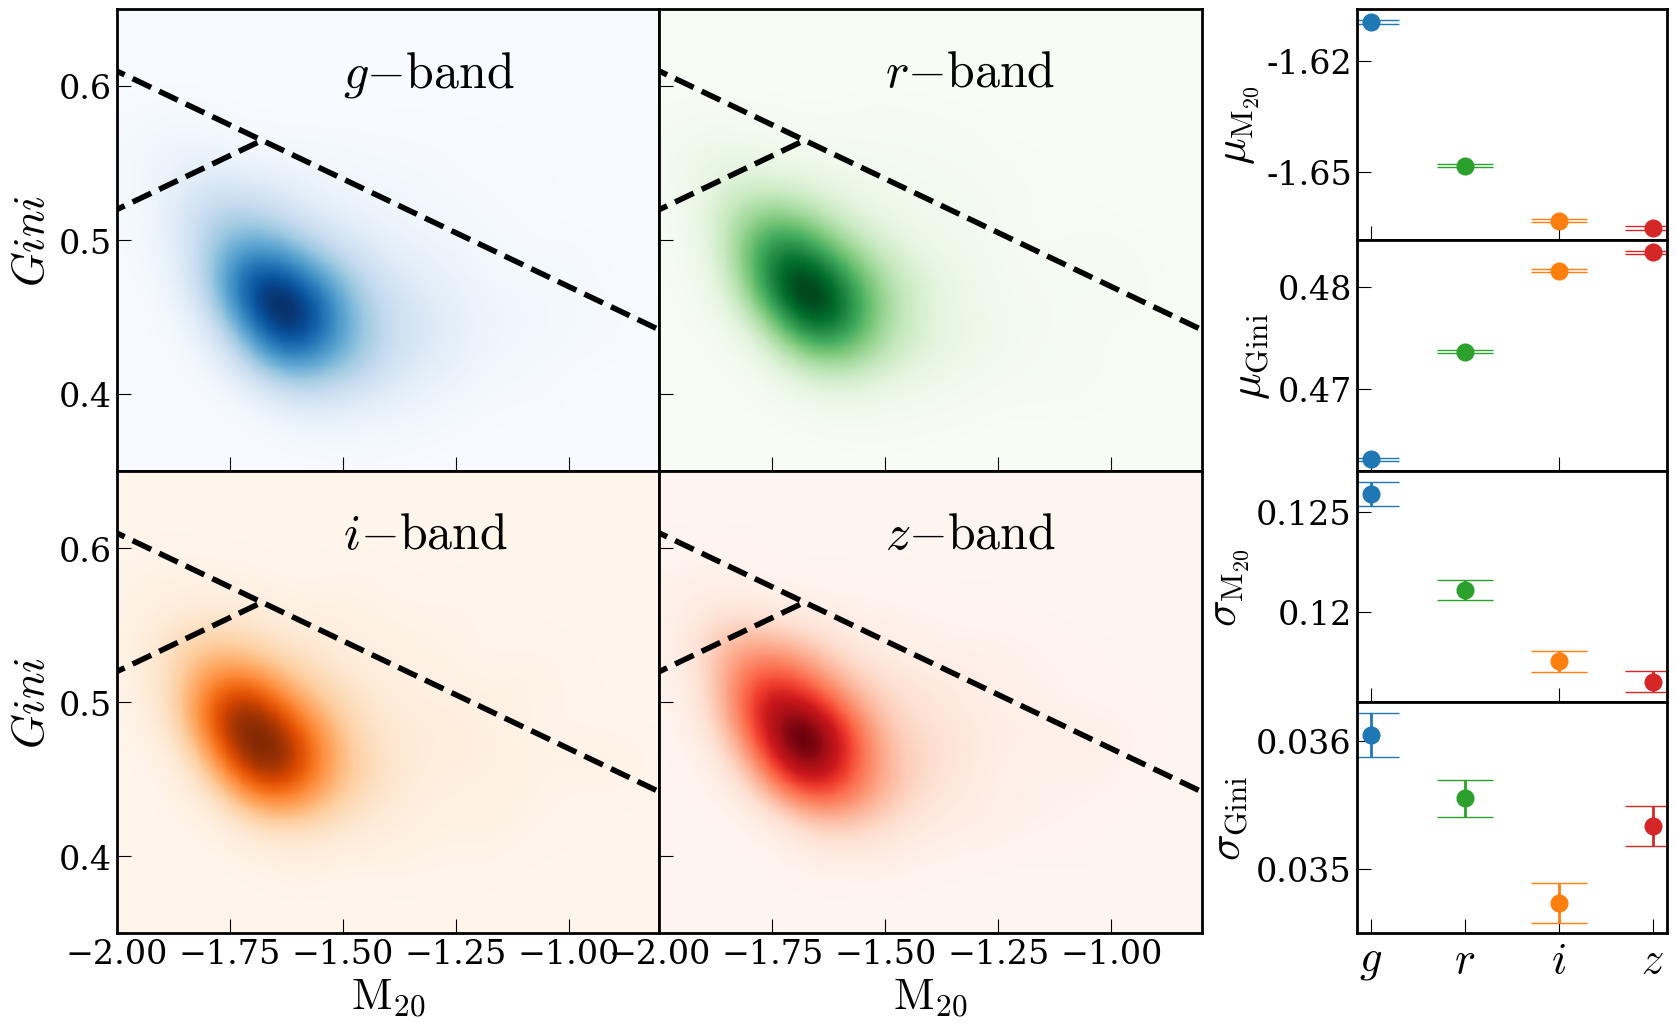

In [13]:
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(4, 4, figure=fig,width_ratios=[0.35,0.35,0.1,0.2])


axl = np.array([[fig.add_subplot(gs[0:2, 0]),fig.add_subplot(gs[0:2, 1])],[fig.add_subplot(gs[2:4, 0]),fig.add_subplot(gs[2:4, 1])]]) # Top-left 2x2
axl[0,0].set_xticklabels([])
axl[0,1].set_yticklabels([])
axl[0,1].set_xticklabels([])
axl[1,1].set_yticklabels([])

axr = [fig.add_subplot(gs[0, 3]),fig.add_subplot(gs[1, 3]),fig.add_subplot(gs[2, 3]),fig.add_subplot(gs[3, 3])] # Bottom-right
axr[0].set_xticklabels([])
axr[1].set_xticklabels([])
axr[2].set_xticklabels([])


hdx = [-2.0,-0.8,0.35,0.65]
M20_arr = np.linspace(-2.2,-0.4,21)
M20_arrhalf = np.linspace(-2.2,-1.68,11)

for i,key in enumerate(bands):

    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    print(selc.shape)

    axl[i//2,i%2].plot(M20_arr,merger_line(M20_arr),lw=4,ls='--',color='black')
    axl[i//2,i%2].plot(M20_arrhalf,hubble_line(M20_arrhalf),lw=4,ls='--',color='black')

    hss_arr,p0,p1 = hess_arr(selc['m20_'+key],selc['gini_'+key], hdx,40)
    
    im = axl[i//2,i%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
    #im = ax[i//2,i%2].scatter(selc['m20_'+key],selc['gini_'+key],c=mst,s=40,cmap=bands[key],vmin=6,vmax=10,alpha=0.8)
    print(p0,p1)
    for j,ley in enumerate(range(4)):
        axr[j].errorbar(i,p0[ley],yerr=p1[ley],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)

    
    axl[i//2,i%2].text(-1.5,0.6,labels[i]+r'$-band$',fontsize=36)
    axl[i//2,i%2].set_ylim((0.35,0.65))
    axl[i//2,i%2].set_xlim((-2.0,-0.8))

for j in range(2):
    axl[j,0].set_ylabel( r'${\it Gini}$',fontsize=32)
    axl[1,j].set_xlabel(r'$M_{20}$',fontsize=32)
    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')
axr[-1].xaxis.set_major_locator(ticker.FixedLocator(positions))
axr[-1].xaxis.set_major_formatter(ticker.FixedFormatter(labels))

tick_form = [[-1.65,-1.62],[0.47,0.48],[0.12,0.125],[3.5e-2,3.6e-2]]
tick_lab = [r'$\mu_{M_{20}}$',r'$\mu_{Gini}$',r'$\sigma_{M_{20}}$',r'$\sigma_{Gini}$']
for i in range(4):
    axr[i].set_ylabel(tick_lab[i],fontsize=32)
    axr[i].yaxis.set_major_locator(ticker.FixedLocator(tick_form[i]))
    axr[i].yaxis.set_major_formatter(ticker.FixedFormatter([str(l) for l in tick_form[i]]))
axr[-1].tick_params(axis='x', labelsize=32)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('GM20loci_fit.pdf',bbox_inches='tight')


In [9]:
zsp_bins = np.logspace(-1.4,-1,5)
print(zsp_bins)
zsp_bw = 0.5*(zsp_bins[1]-zsp_bins[0])

mst_bins = np.linspace(8.0,10.0,5)
print(mst_bins)
mst_bw = 0.5*(mst_bins[1]-mst_bins[0])

gr_bins = np.linspace(0.0,1.0,5)
print(gr_bins)
gr_bw = 0.5*(gr_bins[1]-gr_bins[0])

[0.03981072 0.05011872 0.06309573 0.07943282 0.1       ]
[ 8.   8.5  9.   9.5 10. ]
[0.   0.25 0.5  0.75 1.  ]


(5664, 78)
(459, 78)
(604, 78)
(944, 78)
(767, 78)
(5469, 78)
(455, 78)
(579, 78)
(902, 78)
(724, 78)


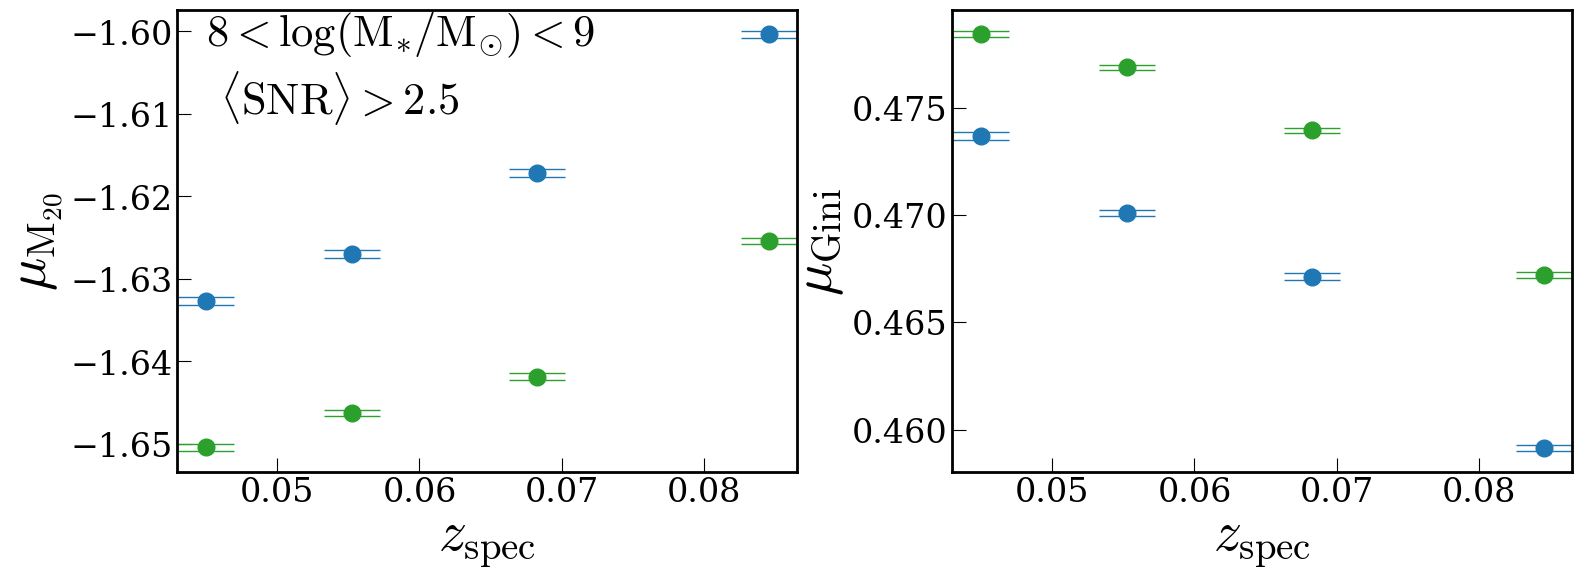

In [11]:
fig,ax=plt.subplots(1,2,figsize=(18,6),sharex='row')

hdx = [-2.0,-1.0,0.4,0.6]

for i,key in enumerate(bands):
    if i>1: continue
    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)]
    zspec = sources['zspec'].iloc[selc['ind1']]
    mst = sources['logM'].iloc[selc['ind1']]
    print(selc.shape)

    p_arr = np.zeros((4,4))
    for j in range(4):
        s_inbin = selc.iloc[np.where((zspec>=zsp_bins[j])&(zspec<zsp_bins[j+1])&(mst>=8)&(mst<9))[0]]
        print(s_inbin.shape)

        hss_arr,p0,p1 = hess_arr(s_inbin['m20_'+key],s_inbin['gini_'+key], hdx,40)
        #im = axl[j//2,j%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
        #p_arr[j,:] = p0[:4]
        for n in range(2):
            ax[n].errorbar(zsp_bins[j]+zsp_bw,p0[n],yerr=p1[n],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)

ax[0].text(0.045,-1.61,r'$8<log(M_{\ast}/M_{\odot})<9$'+'\n '+r'$\langle SNR \rangle>2.5$',fontsize=32)
ax[0].set_ylabel( r'$\mu_{M_{20}}$',fontsize=40)
ax[1].set_ylabel( r'$\mu_{Gini}$',fontsize=40)
ax[0].set_xlabel( r'${\it z}_{spec}$',fontsize=40)
ax[1].set_xlabel( r'${\it z}_{spec}$',fontsize=40)
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.3f}"))


plt.subplots_adjust(wspace=0.25)
plt.savefig('GM20loci_redshift.pdf',bbox_inches='tight')


(3698, 78)
(209, 78)
(1066, 78)
(1209, 78)
(276, 78)
(3947, 78)
(238, 78)
(1154, 78)
(1285, 78)
(287, 78)


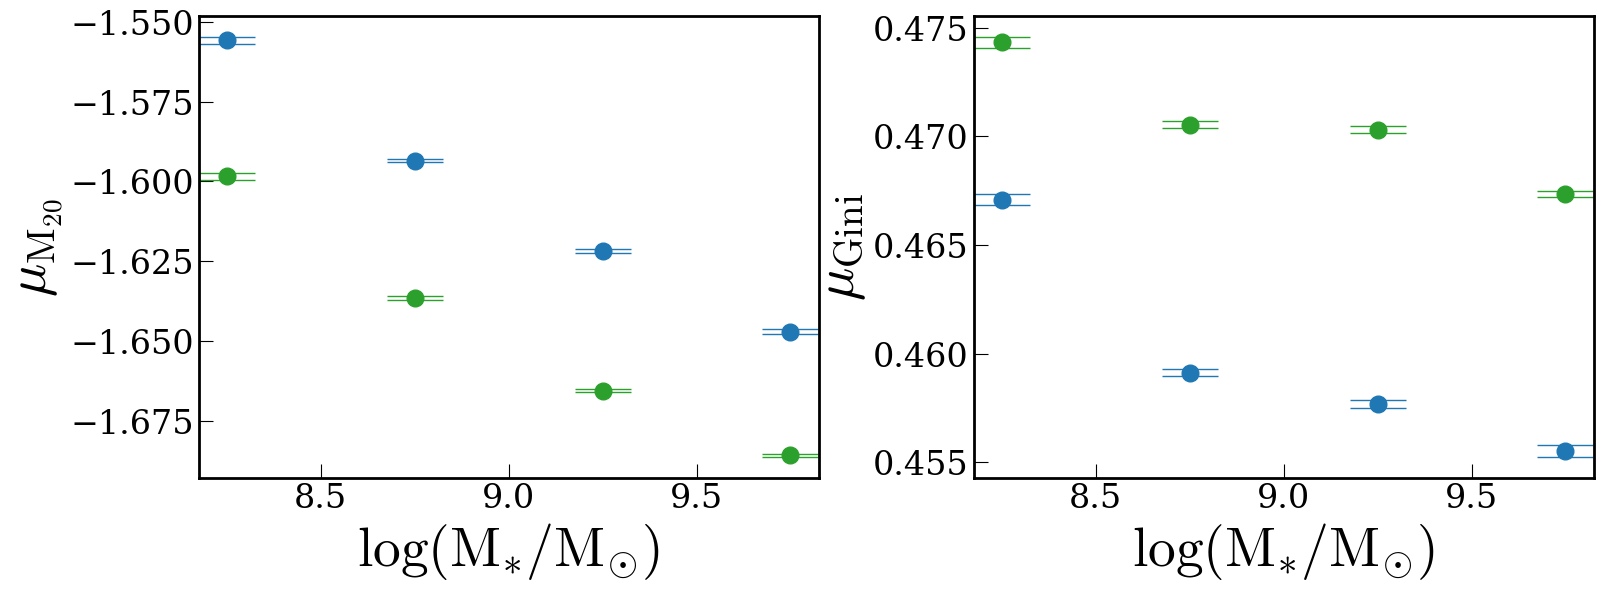

In [12]:
fig,ax=plt.subplots(1,2,figsize=(18,6),sharex='row')

hdx = [-2.0,-1.0,0.4,0.6]

for i,key in enumerate(bands):
    if i>1: continue
    selc = smorph[(smorph['snr_pix_'+key]>2.5)&(smorph['flag_'+key]<=1)&(smorph['r20_psf_'+key]>0.5)]
    zspec = sources['zspec'].iloc[selc['ind1']]
    mst = sources['logM'].iloc[selc['ind1']]
    print(selc.shape)

    p_arr = np.zeros((4,4))
    for j in range(4):
        s_inbin = selc.iloc[np.where((mst>=mst_bins[j])&(mst<mst_bins[j+1])&(zspec>=0.05)&(zspec<0.1))[0]]
        print(s_inbin.shape)

        hss_arr,p0,p1 = hess_arr(s_inbin['m20_'+key],s_inbin['gini_'+key], hdx,40)
        #im = axl[j//2,j%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
        #p_arr[j,:] = p0[1:5]
        for n in range(2):
            ax[n].errorbar(mst_bins[j]+mst_bw,p0[n],yerr=p1[n],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)

#ax[0].text(0.045,-1.61,r'$0.05<{\it z}_{spec}<0.1$'+'\n '+r'$\langle SNR \rangle>2.5$',fontsize=32)
ax[0].set_ylabel( r'$\mu_{M_{20}}$',fontsize=40)
ax[1].set_ylabel( r'$\mu_{Gini}$',fontsize=40)
ax[0].set_xlabel( r'$log(M_{\ast}/M_{\odot})$',fontsize=40)
ax[1].set_xlabel( r'$log(M_{\ast}/M_{\odot})$',fontsize=40)
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.3f}"))


plt.subplots_adjust(wspace=0.25)
#plt.savefig('GM20loci_redshift.pdf',bbox_inches='tight')


(5965, 78)
[ 9.09059384e-03  2.51340750e+00 -1.57728336e-01  2.02493662e-01
  7.52685777e-02  4.88167715e-05] [3.17133363e-05 7.06236496e-04 2.62040383e-04 7.37377362e-04
 2.72696859e-04 4.59045305e-06]
(5873, 78)
[ 8.68604969e-03  2.57343128e+00 -1.17712482e-01  2.07094950e-01
  7.60121952e-02  5.43486792e-05] [3.08668684e-05 7.35744127e-04 2.69890622e-04 7.67027766e-04
 2.81498423e-04 4.58748054e-06]
(3363, 78)
[ 7.94161952e-03  2.62852661e+00 -8.09822605e-02  2.15725813e-01
  8.00873867e-02  5.16171061e-05] [2.60488668e-05 7.07464359e-04 2.62572270e-04 7.40977586e-04
 2.75438983e-04 4.13476043e-06]
(4431, 78)
[ 8.22370522e-03  2.61972861e+00 -8.68475941e-02  2.10546102e-01
  8.05231175e-02  4.22349546e-05] [2.40074326e-05 6.14546877e-04 2.34978002e-04 6.42978404e-04
 2.46213098e-04 3.76256429e-06]


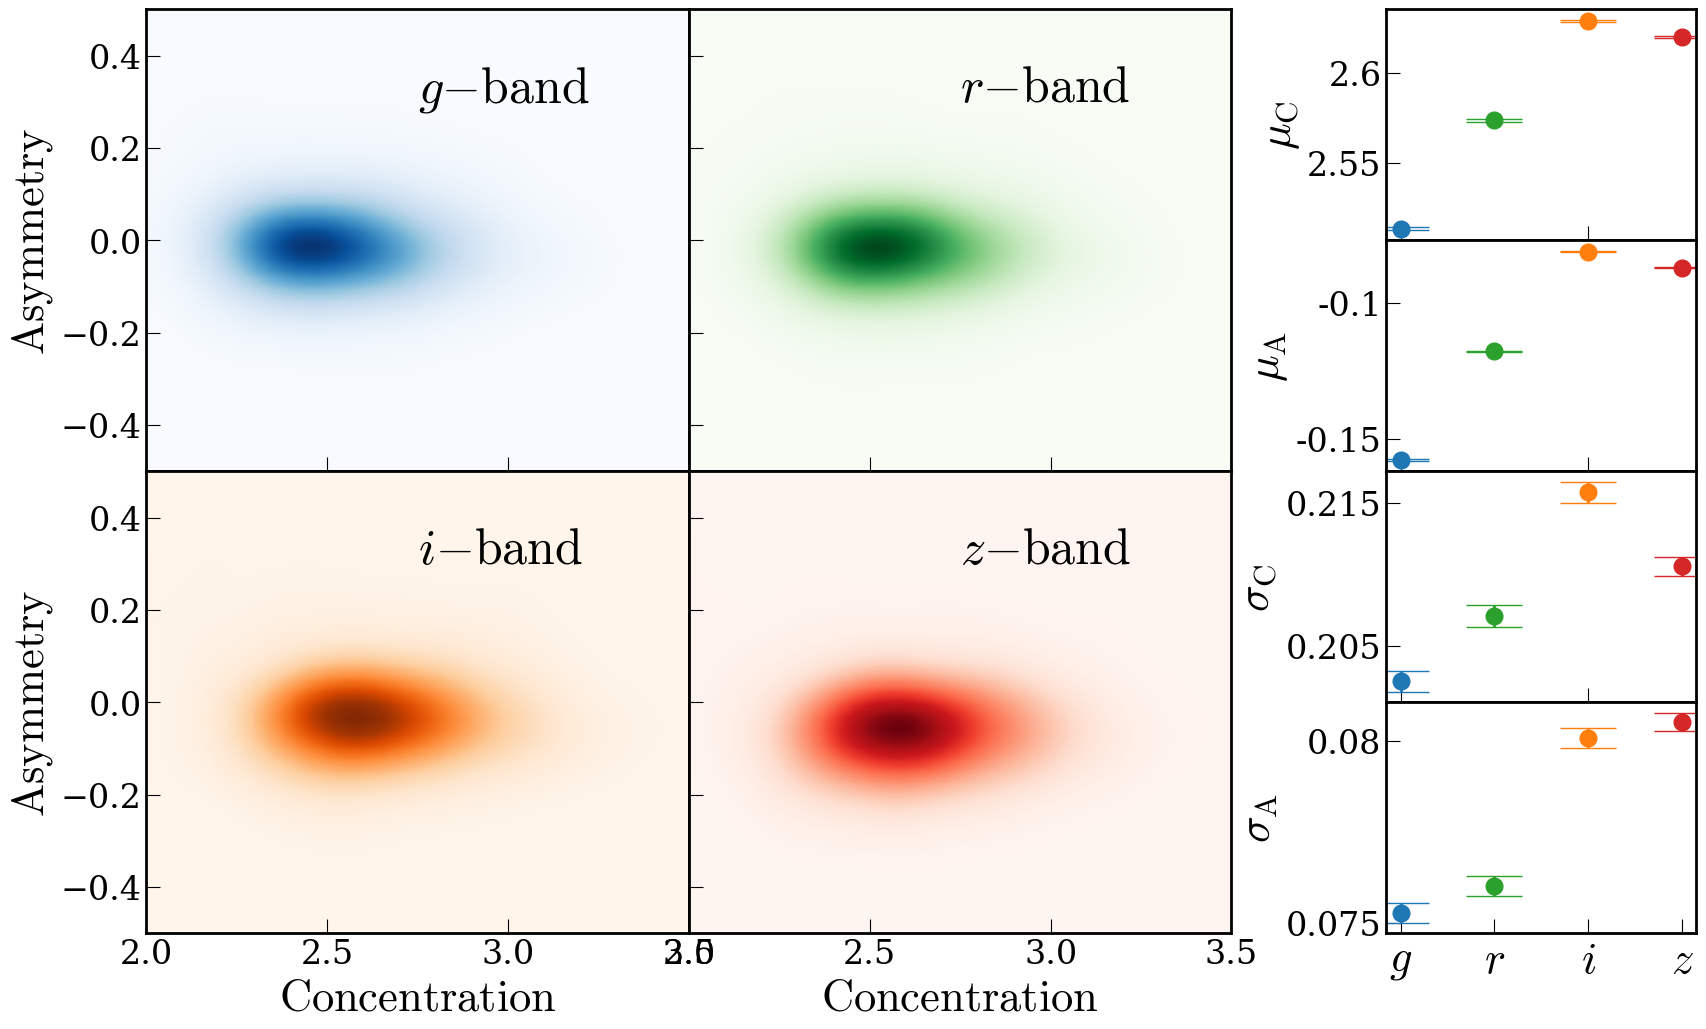

In [13]:
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(4, 4, figure=fig,width_ratios=[0.35,0.35,0.1,0.2])


axl = np.array([[fig.add_subplot(gs[0:2, 0]),fig.add_subplot(gs[0:2, 1])],[fig.add_subplot(gs[2:4, 0]),fig.add_subplot(gs[2:4, 1])]]) # Top-left 2x2
axl[0,0].set_xticklabels([])
axl[0,1].set_yticklabels([])
axl[0,1].set_xticklabels([])
axl[1,1].set_yticklabels([])

axr = [fig.add_subplot(gs[0, 3]),fig.add_subplot(gs[1, 3]),fig.add_subplot(gs[2, 3]),fig.add_subplot(gs[3, 3])] # Bottom-right
axr[0].set_xticklabels([])
axr[1].set_xticklabels([])
axr[2].set_xticklabels([])


hdx = [2.0,3.5,-0.5,0.5]

for i,key in enumerate(bands):

    selc = smorph[(smorph['snr_pix_'+key]>2)&(smorph['flag_'+key]<=1)]
    print(selc.shape)

    hss_arr,p0,p1 = hess_arr(selc['c_'+key],selc['a_'+key], hdx,40)
    im = axl[i//2,i%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')
    #im = ax[i//2,i%2].scatter(selc['m20_'+key],selc['gini_'+key],c=mst,s=40,cmap=bands[key],vmin=6,vmax=10,alpha=0.8)
    print(p0,p1)
    for j,ley in enumerate(range(1,5)):
        axr[j].errorbar(i,p0[ley],yerr=p1[ley],color=bands[key][1],marker='o',markersize=12,elinewidth=2,capsize=20)


    axl[i//2,i%2].text(2.75,0.3,labels[i]+r'$-band$',fontsize=36)
    axl[i//2,i%2].set_ylim((-0.5,0.5))
    axl[i//2,i%2].set_xlim((2.0,3.5))

for j in range(2):
    axl[j,0].set_ylabel( r'$Asymmetry$',fontsize=32)
    axl[1,j].set_xlabel(r'$Concentration$',fontsize=32)
    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')
axr[-1].xaxis.set_major_locator(ticker.FixedLocator(positions))
axr[-1].xaxis.set_major_formatter(ticker.FixedFormatter(labels))

tick_form = [[2.55,2.60],[-0.15,-0.10],[0.205,0.215],[0.075,0.08]]
tick_lab = [r'$\mu_{C}$',r'$\mu_{A}$',r'$\sigma_{C}$',r'$\sigma_{A}$']
for i in range(4):
    axr[i].set_ylabel(tick_lab[i],fontsize=32)
    axr[i].yaxis.set_major_locator(ticker.FixedLocator(tick_form[i]))
    axr[i].yaxis.set_major_formatter(ticker.FixedFormatter([str(l) for l in tick_form[i]]))
axr[-1].tick_params(axis='x', labelsize=32)

plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('ACloci_fit.pdf',bbox_inches='tight')


NameError: name 'sersic_all' is not defined

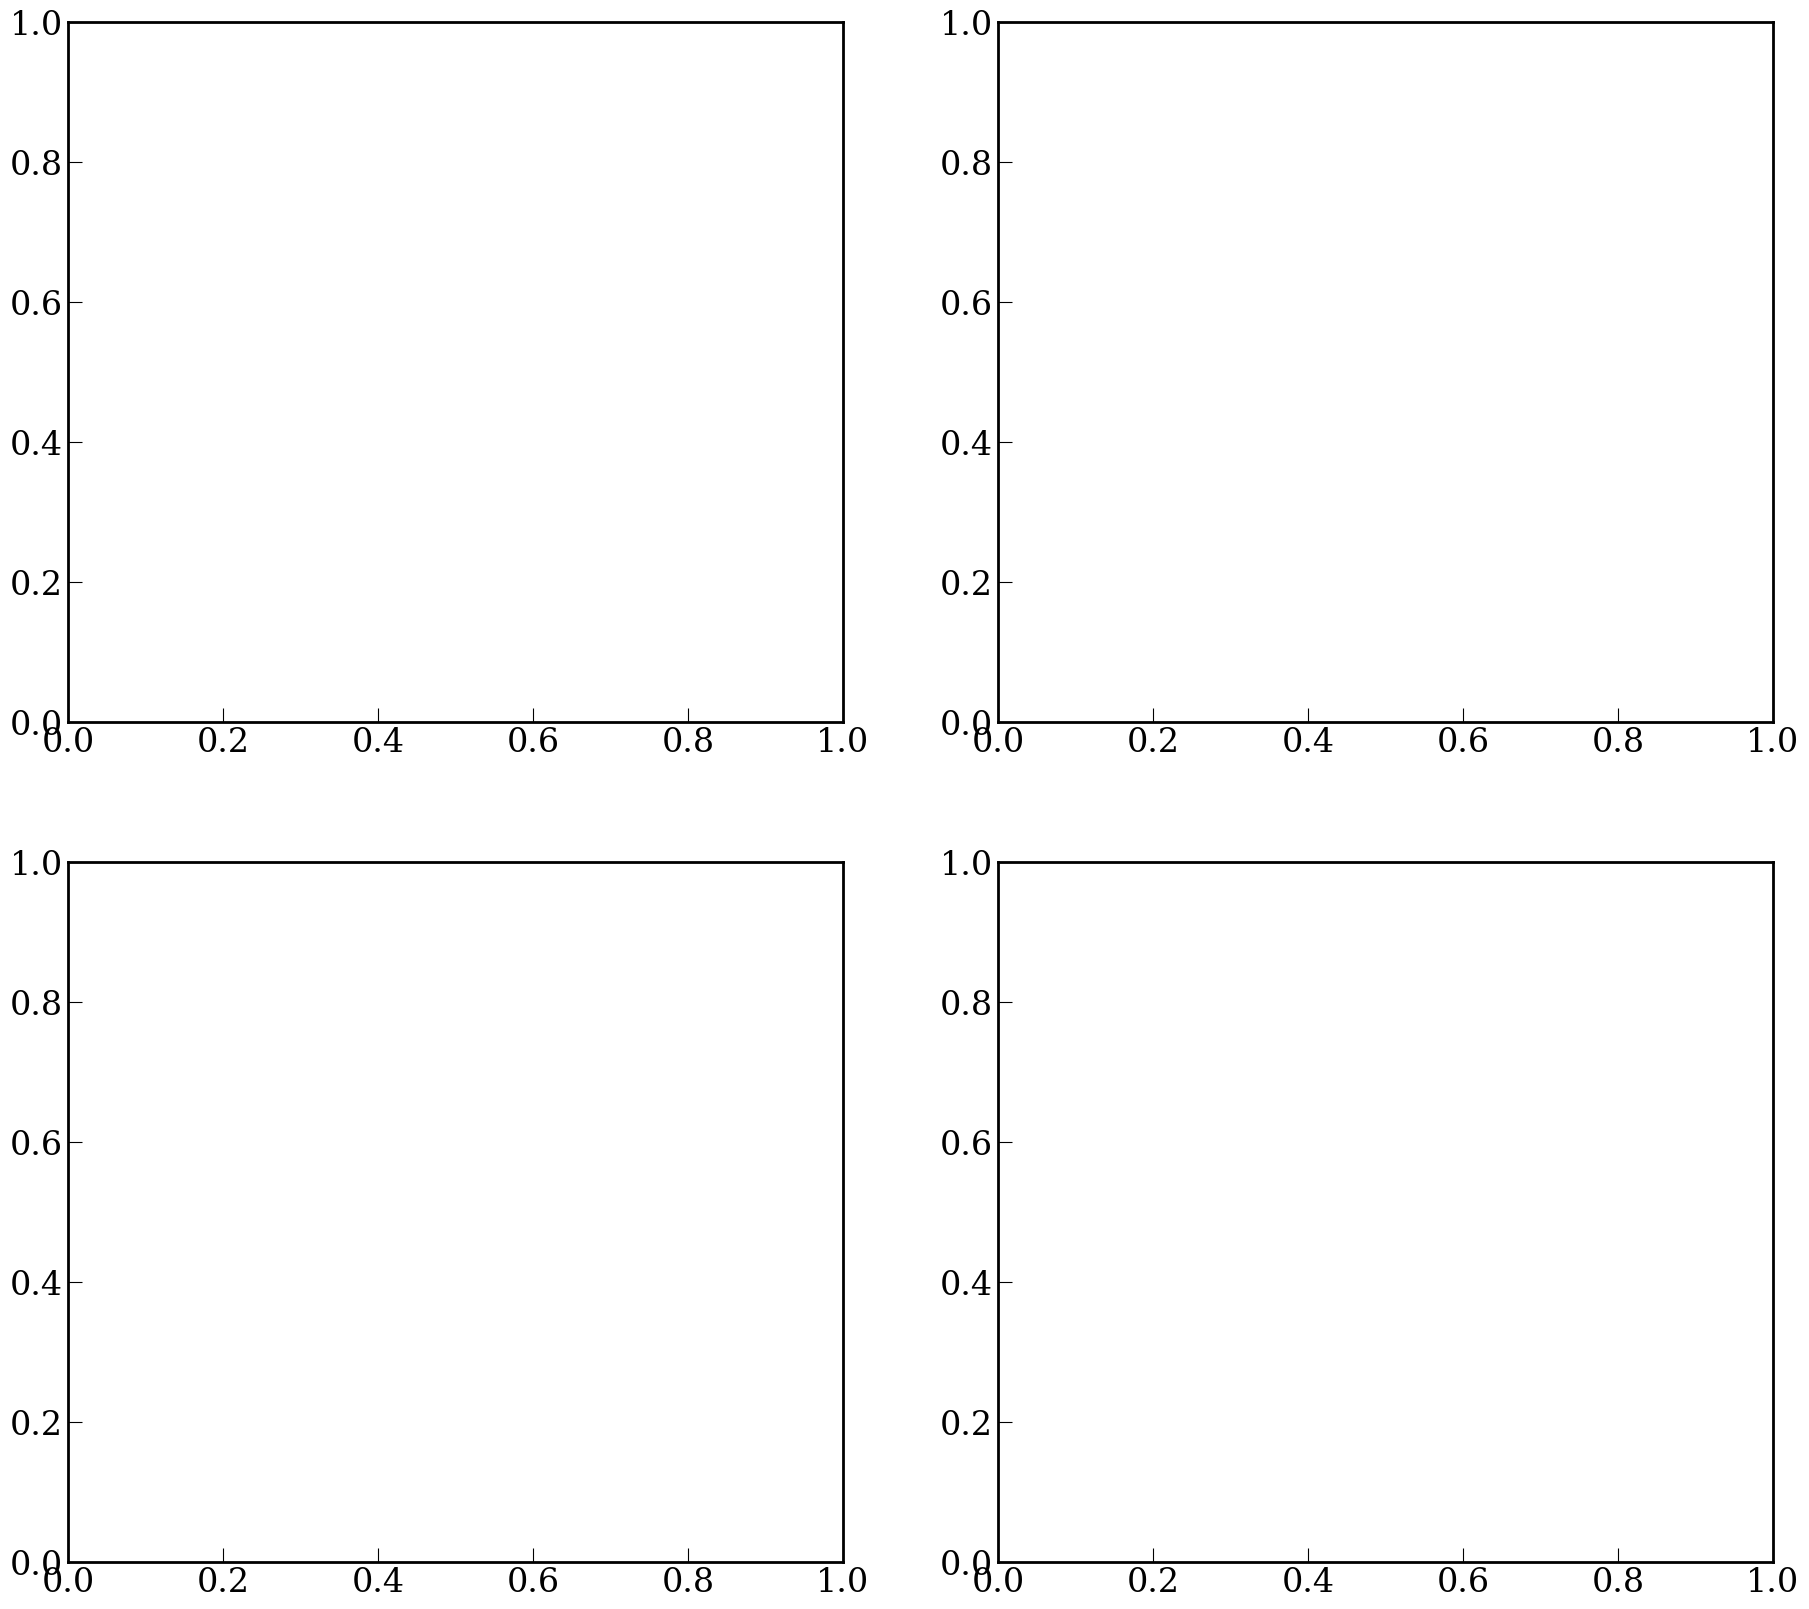

In [71]:
fig,ax=plt.subplots(2,2,figsize=(22,20))

for i,k in enumerate(bands):
    selc = np.where((sersic_all[:,i,3]==0)&(morph_all[:,i,10]>=2))[0]
    if i==2: selc = np.where((sersic_all[:,i,3]==0)&(morph_all[:,i,10]>=2)&(~np.isnan(sources['m_i0'].iloc[morph_all[:,i,0]])))[0]
    print(k,len(selc))
    
    #ax[i//2,i%2].scatter(sersic_all[~selc,i,0],morph_all[~selc,i,5],c=morph_all[~selc,i,8],s=80,cmap=bands[k],vmin=0,vmax=2,alpha=0.3)
    im = ax[i//2,i%2].scatter(sersic_all[selc,i,0],morph_all[selc,i,5],c=morph_all[selc,i,8],s=40,cmap=bands[k],vmin=0,vmax=2,alpha=0.5)


    divider = make_axes_locatable(ax[i//2,i%2])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

    ax[i//2,i%2].set_title(r'${\it '+k+'}-band$',fontsize=44)
    ax[i//2,i%2].set_ylim((2.0,4.0))
    ax[i//2,i%2].set_xlim((0.0,10.0))
    ax[i//2,i%2].set_rasterized(True)

#for j in range(2):
    #ax[j,0].set_ylabel( r'${\it Gini}$',fontsize=40)
    #ax[1,j].set_xlabel(r'$M_{20}$',fontsize=40)
    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')

#plt.subplots_adjust(wspace=0.15)
#plt.savefig('NPdistributions1.pdf',bbox_inches='tight')

(5965, 78)
(5873, 78)
(3363, 78)
(4431, 78)


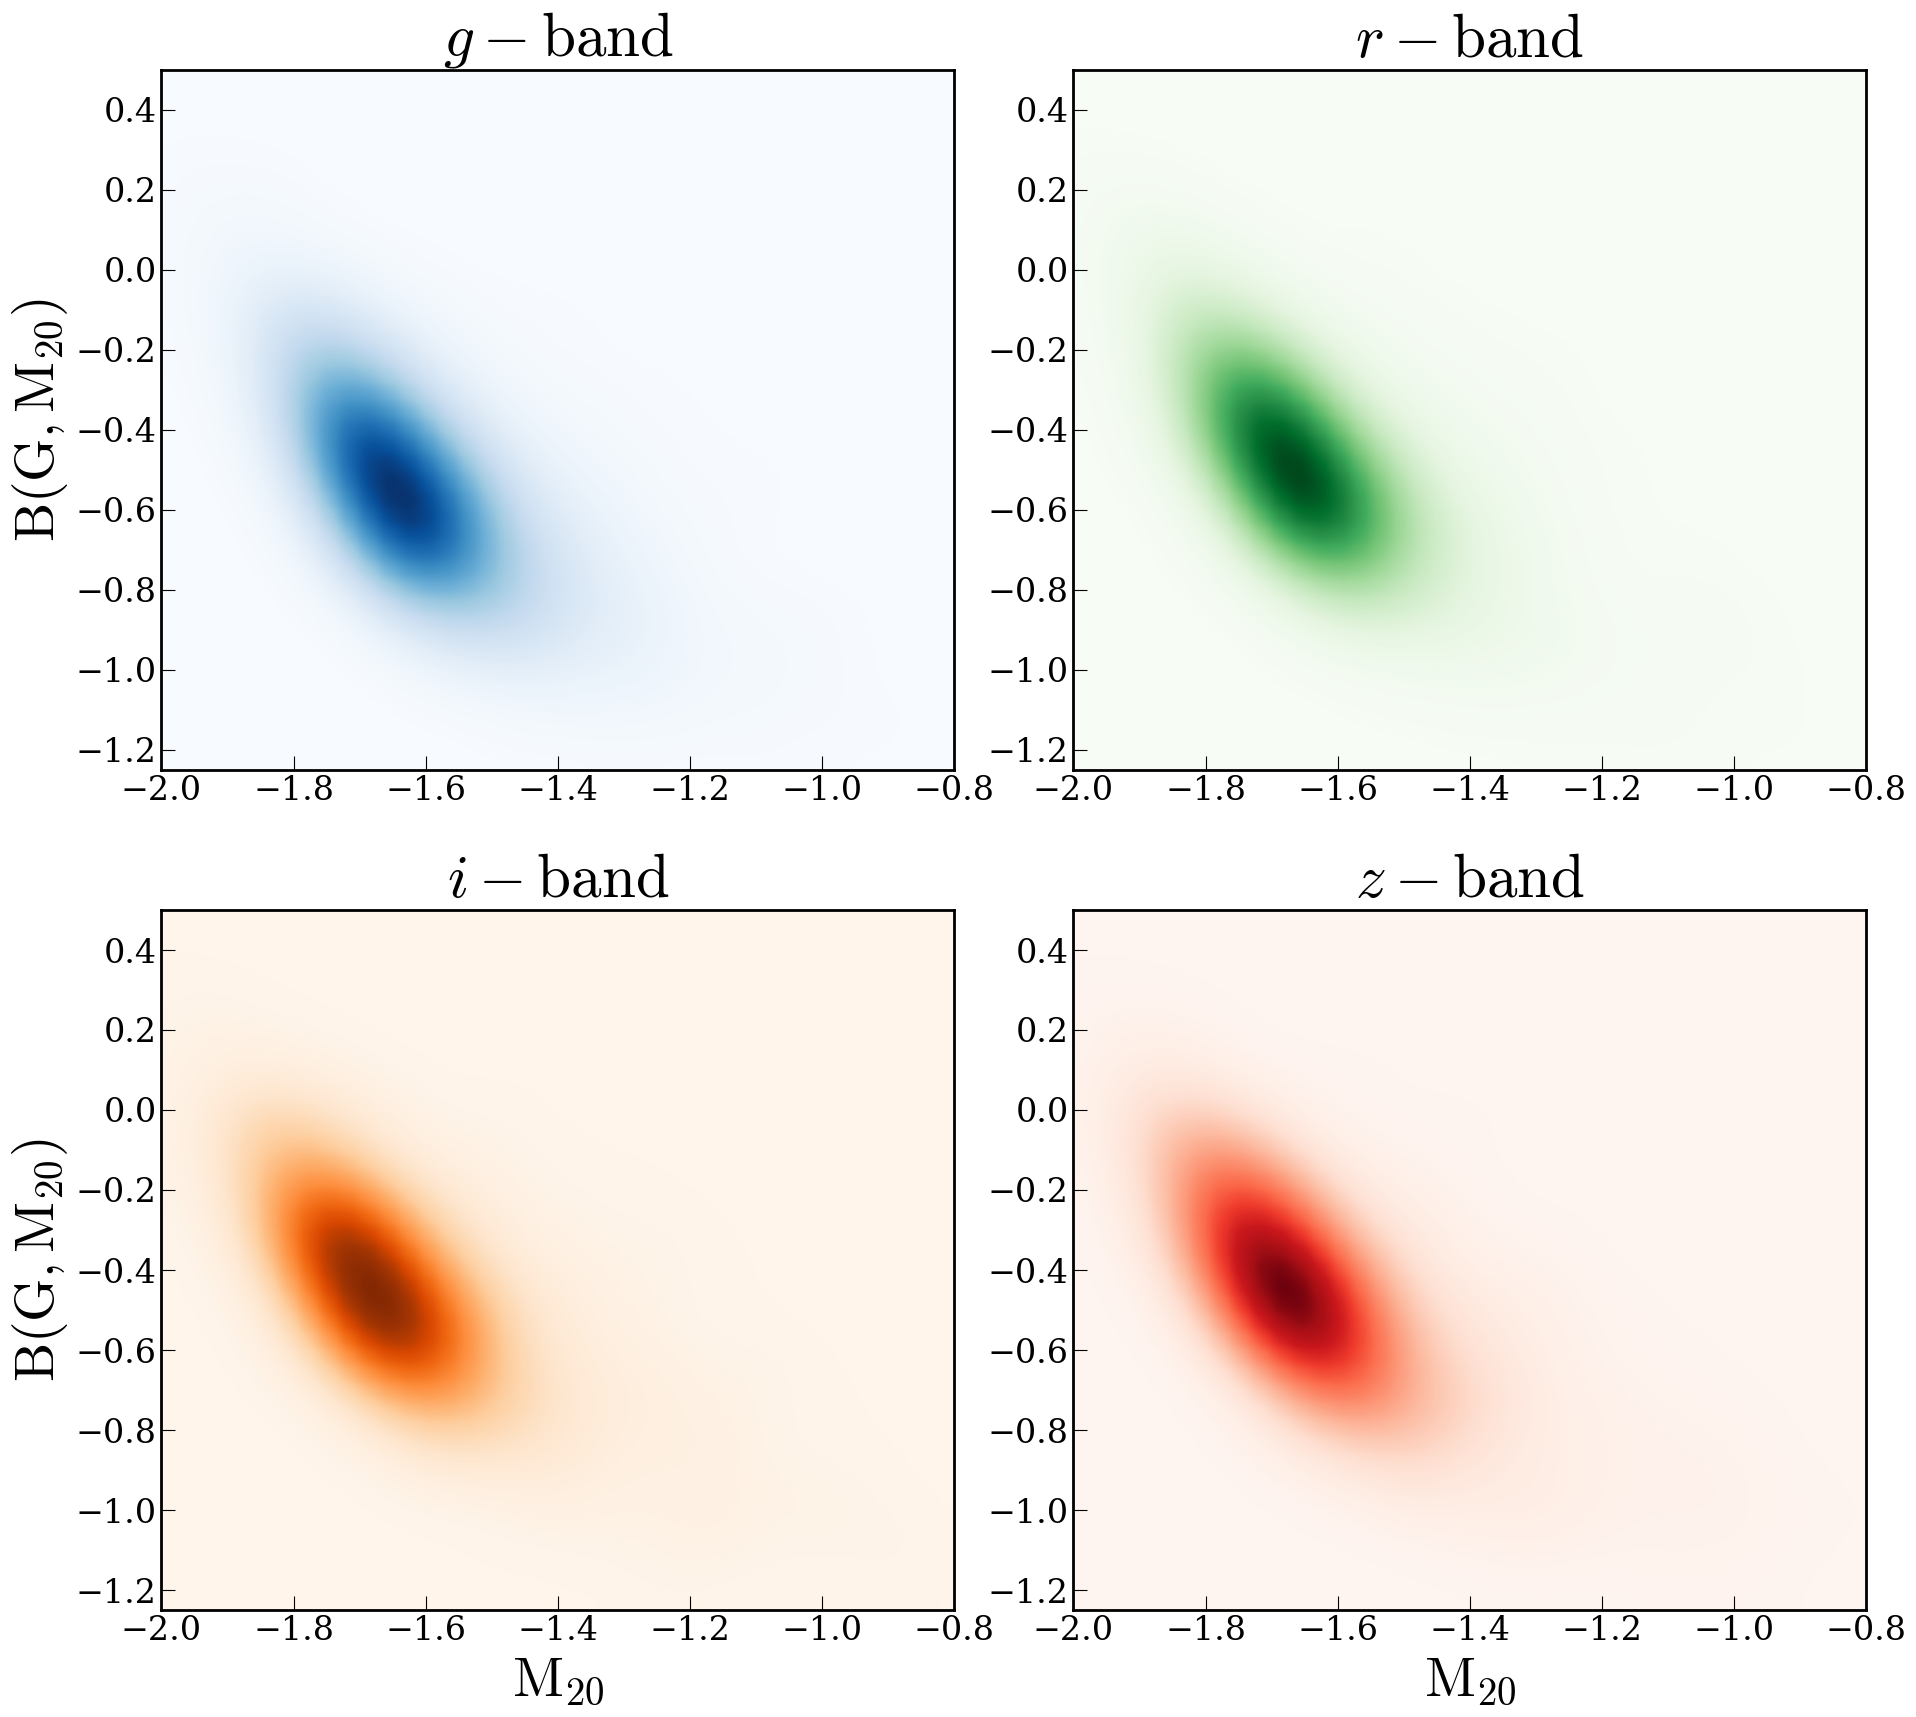

In [9]:
fig,ax=plt.subplots(2,2,figsize=(22,20))

hdx = [-2.0,-0.8,-1.25,0.5]

for i,key in enumerate(bands):
    selc = smorph[(smorph['snr_pix_'+key]>2)&(smorph['flag_'+key]<=1)]
    print(selc.shape)

    mst = sources['logM'].iloc[selc['ind1']]
    hss_arr,p0,p1 = hess_arr(selc['m20_'+key],BGM(selc['gini_'+key],selc['m20_'+key]), hdx,40)
    #im = ax[i//2,i%2].scatter(selc['m20_'+key],BGM(selc['gini_'+key],selc['m20_'+key]),c=mst,s=40,cmap=bands[key][0],vmin=7,vmax=10,alpha=0.8)
    im = ax[i//2,i%2].imshow(hss_arr,cmap=bands[key][0],aspect='auto',extent = hdx,origin='lower',interpolation='gaussian')

    ax[i//2,i%2].set_title(r'${\it '+key+'}-band$',fontsize=44)
    #ax[i//2,i%2].set_ylim((-0.2,0.4))
    ax[i//2,i%2].set_xlim((-2.0,-0.8))

for j in range(2):
    ax[j,0].set_ylabel( r'$B(G,M_{20})$',fontsize=40)
    ax[1,j].set_xlabel(r'$M_{20}$',fontsize=40)



    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')

plt.subplots_adjust(wspace=0.15)
#plt.savefig('NPdistributions1.pdf',bbox_inches='tight')

In [ ]:
#merger_cand = np.where((morph_all[:,0,1]>merger_line(morph_all[:,0,2]))&(morph_all[:,0,2]>-1.5))[0]
merger_cand = high_snr[np.where((morph_all[high_snr,0,8]<0.3))[0]]

fig1,ax1=plt.subplots(1,4,figsize=(32,10),sharey=True)

M20_arr = np.linspace(-2,-0.5,11)
M20_arrhalf = np.linspace(-2,-1.68,11)


for i in range(4):
    mst = sources['logM'].iloc[morph_all[merger_cand,i,0]]
    #dst = np.power(10,sources['logD'].iloc[morph_all[high_snr,i,0]])


    #ax1[i].plot(M20_arr,merger_line(M20_arr),lw=4,ls='--',color='black')
    #ax1[i].plot(M20_arrhalf,hubble_line(M20_arrhalf),lw=4,ls='--',color='black')
    ax1[i].scatter(morph_all[merger_cand,i,8],morph_all[merger_cand,i,1],c=morph_all[merger_cand,i,8],s=120,cmap=filt_cmap[i],vmin=0,vmax=2,edgecolors='black')

    ax1[i].set_ylim((0.3,1.0))
    ax1[i].set_xlim((0,2))
    ax1[i].set_xlabel(r'$M_{20}$',fontsize=40)
    ax1[i].set_rasterized(True)

    plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=filt_cmap[i]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')


ax1[0].set_ylabel( r'${\it Gini}$',fontsize=40)



plt.subplots_adjust(wspace=0.15)
#plt.savefig('NPdistributions1.pdf',bbox_inches='tight')
'''
fig1,ax1=plt.subplots(1,4,figsize=(24,8),sharey=True)

for i in range(4):
    #merger_cand = np.where(morph_all[:,i,1]>merger_line(morph_all[:,i,2]))[0]

    ax1[i].scatter(morph_all[merger_cand,i,2],morph_all[merger_cand,i,1],alpha=0.5,color=griz_col[i],s=40)

for i in range(4):
    #ax1[i].plot(M20_arr,merger_line(M20_arr),lw=3,ls='--',color='black')
    ax1[i].plot(M20_arrhalf,hubble_line(M20_arrhalf),lw=3,ls='--',color='black')
    
    ax1[i].set_ylim((0.3,1.0))
    ax1[i].set_xlim((-2,-0.5))
    ax1[i].set_xlabel(r'$M_{20}$',fontsize=36)
    ax1[i].set_rasterized(True)

ax1[0].set_ylabel( r'${\it Gini}$',fontsize=36)

plt.subplots_adjust(wspace=0.0)
'''
for k in merger_cand:
        key = sources.iloc[k]
        pos = np.array([key['RA'],key['DEC']])
        try: im = plt.imread('post_cutouts/galseg_{:.4f}_{:.4f}.png'.format(pos[0],pos[1]))
        except: continue

        fig,ax=plt.subplots(figsize=(16,8))
        ax.imshow(im)


In [ ]:

fig,ax=plt.subplots(2,2,figsize=(22,20))

M20_arr = np.linspace(-2.2,-0.4,21)
M20_arrhalf = np.linspace(-2.2,-1.68,11)


for i,k in enumerate(bands):

    selc = np.where((morph_all[:,i,9]==0)&(morph_all[:,i,10]>=2))[0]
    print(k,len(selc))
    
    ax[i//2,i%2].scatter(morph_all[~selc,i,2],SGM(morph_all[~selc,i,1],morph_all[~selc,i,2]),c=morph_all[~selc,i,8],s=80,cmap=bands[k],vmin=0,vmax=2,alpha=0.3)
    im = ax[i//2,i%2].scatter(morph_all[selc,i,2],SGM(morph_all[selc,i,1],morph_all[selc,i,2]),c=morph_all[selc,i,8],s=40,cmap=bands[k],vmin=0,vmax=2,alpha=0.5)


    divider = make_axes_locatable(ax[i//2,i%2])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

    ax[i//2,i%2].set_title(r'${\it '+k+'}-band$',fontsize=44)
    ax[i//2,i%2].set_ylim((-0.2,0.4))
    ax[i//2,i%2].set_xlim((-2.2,-0.3))
    ax[i//2,i%2].set_rasterized(True)

for j in range(2):
    ax[j,0].set_ylabel( r'$S(G,M_{20})$',fontsize=40)
    ax[1,j].set_xlabel(r'$M_{20}$',fontsize=40)



    #plt.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=0,vmax=2), cmap=bands[k]), ax=ax1[i],orientation='horizontal',label=r'$A_S$')

#plt.subplots_adjust(wspace=0.15)
#plt.savefig('NPdistributions1.pdf',bbox_inches='tight')